In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
 )

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [16]:
# Load the CSV file with metadata
bee_data = pd.read_csv("../data/processed/processed_bee_data_20260330_151740.csv", sep=';')

display(bee_data.head())

print(bee_data.shape)

display(bee_data.describe(include="all").T)

,file,health,split_group
0,040_070.png,unhealthy,train
1,040_328.png,unhealthy,train
2,010_441.png,healthy,train
3,015_770.png,healthy,train
4,038_149.png,unhealthy,train


(5172, 3)


,count,unique,top,freq
file,5172,5172,040_070.png,1
health,5172,2,healthy,3384
split_group,5172,3,train,4137


In [17]:
# Necessary features (X) and target (y)
x = bee_data[['file']].copy()
y = bee_data['health'].copy()

# Use the predefined split groups from processed metadata
split_col = bee_data['split_group'].str.lower()

x_train = x[split_col == 'train']
y_train = y[split_col == 'train']

x_val = x[split_col == 'val']
y_val = y[split_col == 'val']

x_test = x[split_col == 'test']
y_test = y[split_col == 'test']

# Shape / # rows, # columns for each split
print("Training")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print("\nValidation")
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")
print("\nTesting")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}\n")

# Number of unique classes
num_classes_train = len(np.unique(y_train))
num_classes_val = len(np.unique(y_val))
num_classes_test = len(np.unique(y_test))

print(f"Number of classes in training set: {num_classes_train}")
print(f"Number of classes in validation set: {num_classes_val}")
print(f"Number of classes in test set: {num_classes_test}\n")

print(bee_data[['file', 'split_group']].head(10), "\n")
print(bee_data['split_group'].value_counts())

Training
x_train shape: (4137, 1)
y_train shape: (4137,)

Validation
x_val shape: (517, 1)
y_val shape: (517,)

Testing
x_test shape: (518, 1)
y_test shape: (518,)

Number of classes in training set: 2
Number of classes in validation set: 2
Number of classes in test set: 2

           file split_group
0   040_070.png       train
1   040_328.png       train
2   010_441.png       train
3   015_770.png       train
4   038_149.png       train
5   032_361.png       train
6  019_1354.png       train
7  015_1260.png       train
8   032_547.png       train
9   040_363.png       train 

split_group
train    4137
test      518
val       517
Name: count, dtype: int64


Same number of unique classes in health condition label of training and test set.

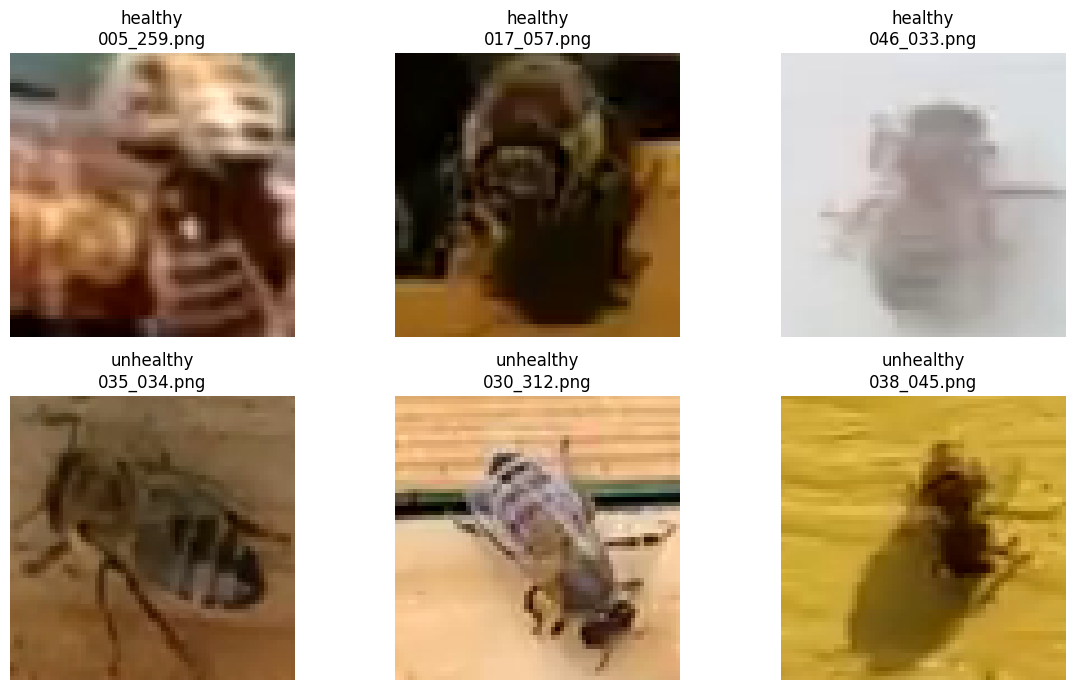

In [18]:
# Show only 6 random training images (3 healthy, 3 unhealthy) without preloading all images
class_names = ["healthy", "unhealthy"]

# Convert labels to a NumPy array for easier indexing
y_train_labels = y_train.astype(str).str.lower().to_numpy()

# Indices by class
healthy_indices = np.where(y_train_labels == "healthy")[0]
unhealthy_indices = np.where(y_train_labels == "unhealthy")[0]

# Load and resize only selected images for faster preview
def load_preview_image(filename, preview_size=(64, 64)):
    img_path = os.path.join("../data/bee_imgs", filename)
    with Image.open(img_path) as img:
        img = img.convert("RGB")
        img = img.resize(preview_size)
        return np.array(img)

# Sample 3 images from each class
n_per_class = 3
healthy_pick = np.random.choice(
    healthy_indices,
    size=n_per_class,
    replace=len(healthy_indices) < n_per_class
)
unhealthy_pick = np.random.choice(
    unhealthy_indices,
    size=n_per_class,
    replace=len(unhealthy_indices) < n_per_class
)

# Combine picks so first row is healthy, second row is unhealthy
picked_indices = np.concatenate([healthy_pick, unhealthy_pick])

plt.figure(figsize=(12, 7))
for i, index in enumerate(picked_indices):
    plt.subplot(2, 3, i + 1)

    filename = x_train.iloc[index, 0]
    label = y_train.iloc[index]
    preview_img = load_preview_image(filename)
    plt.imshow(preview_img)

    plt.title(f"{label}\n{filename}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Images resized and randomly chosen so we don't load all of them into memory at once just for visualization.

Train samples: 4137
Validation samples: 517
Test samples: 518
Image size: 128x128, batch size: 32


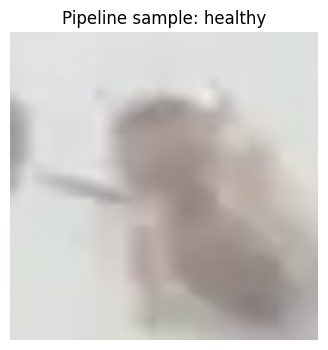

In [19]:
# Build an efficient input pipeline: load -> resize -> normalize -> batch -> prefetch
import tensorflow as tf

IMG_SIZE = 128
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Encode labels once; one-hot conversion happens inside the pipeline
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train.astype(str))
y_val_encoded = label_encoder.transform(y_val.astype(str))
y_test_encoded = label_encoder.transform(y_test.astype(str))
num_classes = len(label_encoder.classes_)

def make_paths(file_series):
    return file_series.astype(str).apply(
        lambda name: os.path.join("../data/bee_imgs", name)
    ).to_numpy()

train_paths = make_paths(x_train.iloc[:, 0])
val_paths = make_paths(x_val.iloc[:, 0])
test_paths = make_paths(x_test.iloc[:, 0])

def load_and_preprocess(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0 # normalization
    image.set_shape((IMG_SIZE, IMG_SIZE, 3))
    label = tf.one_hot(label, depth=num_classes)
    return image, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, y_train_encoded, training=True)
val_ds = make_dataset(val_paths, y_val_encoded, training=False)
test_ds = make_dataset(test_paths, y_test_encoded, training=False)

print(f"Train samples: {len(train_paths)}")
print(f"Validation samples: {len(val_paths)}")
print(f"Test samples: {len(test_paths)}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}, batch size: {BATCH_SIZE}")

# Show one preprocessed sample image
for sample_images, sample_labels in train_ds.take(1):
    sample_image = sample_images[0].numpy()
    sample_label_idx = int(tf.argmax(sample_labels[0]).numpy())
    sample_label_name = label_encoder.inverse_transform([sample_label_idx])[0]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image)
plt.title(f"Pipeline sample: {sample_label_name}")
plt.axis("off")
plt.show()

In [20]:
# Labels are already encoded and converted to one-hot in the tf.data pipeline
print(f"Classes: {list(label_encoder.classes_)}")
print(f"Number of classes: {num_classes}")

train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

print(f"Train batches: {train_batches}")
print(f"Validation batches: {val_batches}")
print(f"Test batches: {test_batches}")

Classes: ['healthy', 'unhealthy']
Number of classes: 2
Train batches: 130
Validation batches: 17
Test batches: 17


In [7]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))
# GPU list is empty, staying on CPU

TensorFlow: 2.20.0
GPUs: []


In [28]:
# 3. Build and train a simple CNN baseline (close to the original)

# MODEL 1: Simple CNN (not overcomplicated)
from tensorflow.keras.layers import BatchNormalization  # optional but lightweight

model_basic = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2, 2),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(64, activation='relu', name='feature_dense_64'),
    Dropout(0.30),
    Dense(num_classes, activation='softmax')
], name='simple_cnn_v2')

model_basic.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("=" * 50)
print("MODEL 1: Simple CNN")
print("=" * 50)
model_basic.summary()

# Note: this is still simple. If needed, we can go back to the absolute minimum one-conv model.

MODEL 1: Simple CNN


c:\Users\palag\Documents\Egyetem\THESIS\beeproject-cnn\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "simple_cnn_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_dense_64 (Dense)        │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,482 (7.05 MB)

 Trainable params: 1,848,482 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# 4. Train the simple CNN
print("\nTraining the simple CNN model...")

from tensorflow.keras.callbacks import EarlyStopping

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        mode='min',
        start_from_epoch=5,
        restore_best_weights=True,
        verbose=1
    )
]

history = model_basic.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

# 5. Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_accuracy = model_basic.evaluate(test_ds)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
best_val_loss = history.history['val_loss'][best_epoch - 1]
print(f"Best epoch by val_loss: {best_epoch}")
print(f"val_loss of best epoch: {best_val_loss:.4f}")


Training the simple CNN model...
Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.7974 - loss: 0.4589 - val_accuracy: 0.9265 - val_loss: 0.2076
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9055 - loss: 0.2435 - val_accuracy: 0.9613 - val_loss: 0.1309
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9316 - loss: 0.1838 - val_accuracy: 0.9652 - val_loss: 0.0907
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9570 - loss: 0.1261 - val_accuracy: 0.9749 - val_loss: 0.0906
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9654 - loss: 0.1022 - val_accuracy: 0.9652 - val_loss: 0.0833
Epoch 6/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.9790 - loss: 0.0649 - val_accuracy: 0.9845 - val_loss: 0.0555
Epoch 7/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9819 - loss: 0.0586 - val_accuracy: 0.9749 - val_loss: 0.0596
Epoch 8/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy

In [30]:
## DISCLAIMER: Only run this cell if you want to save the model, it is a bigger file
# Save full trained model (architecture + weights + optimizer state)
model_basic.save("best_cnn.keras")
print("Saved:", os.path.abspath("best_cnn.keras"))

Saved: c:\Users\palag\Documents\Egyetem\THESIS\beeproject-cnn\models\best_cnn.keras


From this plot, the best checkpoint is most likely around epoch 13!.

Why:

Validation loss (orange, right plot) reaches its lowest point around epoch 9, then rises and becomes unstable.
Validation accuracy (orange, left plot) is near its peak around epochs 9 to 13, but at epoch 14 it drops sharply.
The last epoch is clearly worse (validation loss jump + validation accuracy drop), so you would not pick it.
Practical rule:

Pick the epoch with minimum validation loss (usually best generalization).
Use validation accuracy as a secondary check.

So the final model is from the best epoch by the monitored metric.

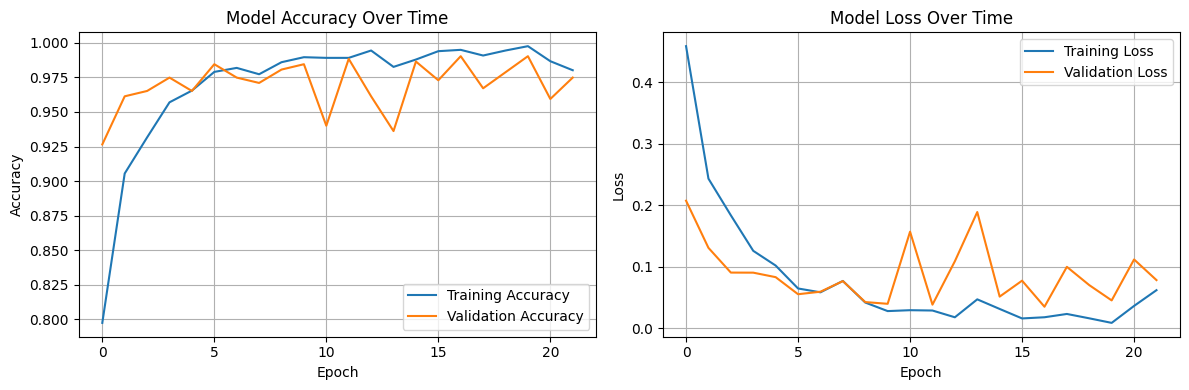

In [31]:
# 6. Plot training history
plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Time')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Test set classification report:
              precision    recall  f1-score   support

     healthy       0.98      0.99      0.99       339
   unhealthy       0.99      0.97      0.98       179

    accuracy                           0.98       518
   macro avg       0.99      0.98      0.98       518
weighted avg       0.98      0.98      0.98       518

Summary metrics (positive class = unhealthy):
Accuracy:  0.9846
Precision: 0.9886
Recall:    0.9665
F1-score:  0.9774
ROC AUC:   0.9977


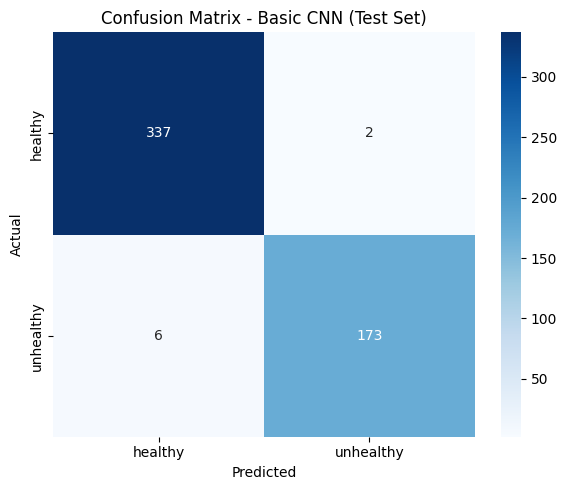

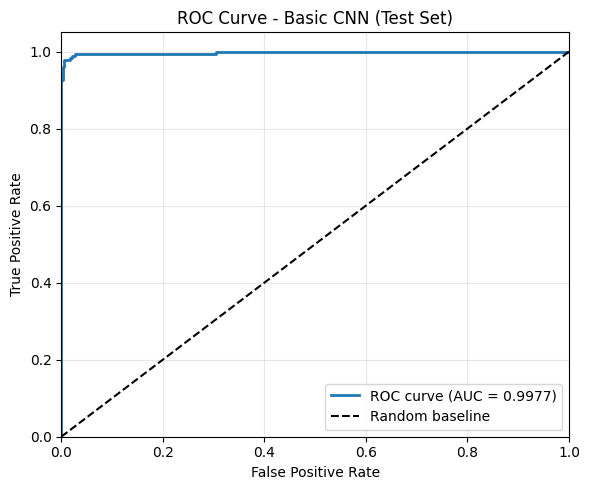

In [32]:
# 7. Final test set evaluation (CNN)
y_pred_proba = model_basic.predict(test_ds)
y_pred_classes = np.argmax(y_pred_proba, axis=1)

# Convert predictions back to original string labels for easier reporting
y_pred_labels = label_encoder.inverse_transform(y_pred_classes)
y_test_labels = y_test.astype(str).to_numpy()

# Core metrics on the held-out test set
acc = accuracy_score(y_test_labels, y_pred_labels)
prec = precision_score(y_test_labels, y_pred_labels, pos_label="unhealthy")
rec = recall_score(y_test_labels, y_pred_labels, pos_label="unhealthy")
f1 = f1_score(y_test_labels, y_pred_labels, pos_label="unhealthy")

# ROC-AUC (positive class = unhealthy)
positive_label = "unhealthy"
positive_class_index = int(np.where(label_encoder.classes_ == positive_label)[0][0])
y_test_binary = (y_test_labels == positive_label).astype(int)
y_pred_positive_proba = y_pred_proba[:, positive_class_index]
roc_auc = roc_auc_score(y_test_binary, y_pred_positive_proba)
fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_positive_proba)

print("Test set classification report:")
print(classification_report(y_test_labels, y_pred_labels))

print("Summary metrics (positive class = unhealthy):")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")

# Confusion matrix visualization
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=["healthy", "unhealthy"])
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["healthy", "unhealthy"],
    yticklabels=["healthy", "unhealthy"],
)
plt.title("Confusion Matrix - Basic CNN (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curve visualization
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Basic CNN (Test Set)")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Precision: When it says 1 how often is it right
Recall/Sensitivity: What fraction of 1s does it get right
(True Positive Rate – TPR)
F1-score: How “good” are precision and recall

**Strong performance:**

In [ ]:
# Employ validation split? and write in thesis
# Do early stop for NN? early stopping in neural networks to prevent overfitting